# KosMate - Model Regresi & Clustering

Notebook ini berisi pipeline lengkap: preprocessing, regresi harga kos menggunakan Random Forest, clustering KMeans, evaluasi, visualisasi, dan logging MLflow.

## 1. Import Library & Load Data

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import joblib
import mlflow
import mlflow.sklearn

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    silhouette_score,
    silhouette_samples
)
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans

In [10]:
pip install mlflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\amel\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [11]:
df = pd.read_csv("../data/Kos_Clean.csv")

df.head()

,Nama Kos,Alamat,Jenis,Harga,WiFi,AC,Dapur,Listrik,Kamar mandi,Jarak dari PENS,Nomor pemilik kos
0,Kos Muslimah,Keputih gang 2b nomor 28,Khusus Perempuan,800000,Ada,Tidak,Ada,Include,Luar,2.8,+62 895-3970-76143
1,Kos The Gayam,Jalan wismpa permai ix no 21,Khusus Perempuan,1600000,Ada,Ada,Ada,Exclude,Luar,2.4,+62 811-314-413
2,Griya Risny TMB 114,Tegal Mulyorejo Baru No.114,Khusus Perempuan,800000,Ada,Tidak,Ada,Include,Luar,1.0,081259401184
3,Kos Khoirul Huda,Jalan Semampir Selatan IIA,Campur,275000,Ada,Tidak,Ada,Include,Luar,6.0,081230303153
4,Kos pak Mirza E20,"Keputih Gg makam, Blok E20",Khusus Laki Laki,450000,Ada,Tidak,Tidak,Include,Luar,3.3,+62 851-0091-8223


## 2. Preprocessing & Encoding

In [12]:
mapping_ada = {
    "Ada": 1,
    "Tidak": 0
}

mapping_listrik = {
    "Include": 1,
    "Exclude": 0
}

mapping_km = {
    "Dalam": 1,
    "Luar": 0
}

## 3. Regresi - Random Forest

In [13]:
df_regresi = df.copy()

df_regresi["WiFi"] = df_regresi["WiFi"].map(mapping_ada)
df_regresi["AC"] = df_regresi["AC"].map(mapping_ada)
df_regresi["Dapur"] = df_regresi["Dapur"].map(mapping_ada)
df_regresi["Listrik"] = df_regresi["Listrik"].map(mapping_listrik)
df_regresi["Kamar mandi"] = df_regresi["Kamar mandi"].map(mapping_km)

df_regresi["Skor_Fasilitas"] = (
    df_regresi["WiFi"] +
    df_regresi["AC"] +
    df_regresi["Dapur"] +
    df_regresi["Kamar mandi"]
)

df_regresi = pd.get_dummies(
    df_regresi,
    columns=["Jenis"]
)

fitur_regresi = [
    "Jarak dari PENS",
    "WiFi",
    "AC",
    "Dapur",
    "Listrik",
    "Kamar mandi",
    "Skor_Fasilitas",
    "Jenis_Campur",
    "Jenis_Khusus Laki Laki",
    "Jenis_Khusus Perempuan"
]

X = df_regresi[fitur_regresi]
y = df_regresi["Harga"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", None]
}

grid = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42
    ),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

In [15]:
pred = best_rf.predict(X_test)

r2   = r2_score(y_test, pred)
mae  = mean_absolute_error(y_test, pred)
rmse = mean_squared_error(y_test, pred) ** 0.5
mape = mean_absolute_percentage_error(y_test, pred)

print("=" * 50)
print("HASIL RANDOM FOREST")
print("=" * 50)
print("Best Parameter :")
print(grid.best_params_)
print("\nR2   :", r2)
print("MAE  :", mae)
print("RMSE :", rmse)
print("MAPE :", mape)

HASIL RANDOM FOREST
Best Parameter :
{'max_depth': 5, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}

R2   : 0.7452526814647669
MAE  : 158781.46349857218
RMSE : 229334.63346946883
MAPE : 0.1688854203237926


## 4. Clustering - KMeans

In [16]:
df_cluster = df.copy()

df_cluster["WiFi"] = df_cluster["WiFi"].map(mapping_ada)
df_cluster["AC"] = df_cluster["AC"].map(mapping_ada)
df_cluster["Dapur"] = df_cluster["Dapur"].map(mapping_ada)
df_cluster["Listrik"] = df_cluster["Listrik"].map(mapping_listrik)
df_cluster["Kamar mandi"] = df_cluster["Kamar mandi"].map(mapping_km)

df_cluster = pd.get_dummies(
    df_cluster,
    columns=["Jenis"]
)

fitur_cluster = [
    "Harga",
    "Jarak dari PENS",
    "WiFi",
    "AC",
    "Dapur",
    "Listrik",
    "Kamar mandi",
    "Jenis_Campur",
    "Jenis_Khusus Laki Laki",
    "Jenis_Khusus Perempuan"
]

data_cluster = df_cluster[fitur_cluster]

scaler = MinMaxScaler()
X_cluster = scaler.fit_transform(data_cluster)

### 4.1 Tuning Jumlah Cluster

In [17]:
hasil_cluster = []

for k in range(2, 21):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_cluster)

    score = silhouette_score(
        X_cluster,
        labels
    )

    hasil_cluster.append({
        "Jumlah_Cluster": k,
        "Silhouette_Score": score
    })

hasil_cluster = pd.DataFrame(hasil_cluster)

display(hasil_cluster)

C:\Users\amel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\amel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.

,Jumlah_Cluster,Silhouette_Score
0,2,0.313346
1,3,0.312662
2,4,0.375247
3,5,0.375910
4,6,0.385759
5,7,0.406257
6,8,0.430919
7,9,0.454583
8,10,0.468619
9,11,0.483978


### 4.2 Model Final KMeans

In [18]:
kmeans = KMeans(
    n_clusters=15,
    random_state=42,
    n_init=10
)

cluster = kmeans.fit_predict(X_cluster)

df["Cluster_KMeans"] = cluster

print("=" * 50)
print("JUMLAH DATA TIAP CLUSTER")
print("=" * 50)
print(
    df["Cluster_KMeans"]
    .value_counts()
    .sort_index()
)

print("\n")

print("=" * 50)
print("SILHOUETTE SCORE")
print("=" * 50)
print(
    silhouette_score(
        X_cluster,
        cluster
    )
)

JUMLAH DATA TIAP CLUSTER
Cluster_KMeans
0     17
1     20
2     17
3     22
4     15
5      6
6      5
7      7
8     11
9     14
10     6
11     7
12     2
13     5
14     6
Name: count, dtype: int64


SILHOUETTE SCORE
0.5545349461850078


# 4.3 Menambahkan kolom cluster

In [19]:
# =========================
# SAVE CSV FINAL
# =========================

df.to_csv(
    "../data/Kos_Clean.csv",
    index=False
)

print("CSV berhasil diperbarui")

CSV berhasil diperbarui


## 5. Simpan Model

In [20]:
joblib.dump(best_rf, "model_rf.pkl")
joblib.dump(kmeans, "model_kmeans.pkl")
joblib.dump(scaler, "model_scaler.pkl")

print("Model berhasil disimpan!")

Model berhasil disimpan!


## 6. Visualisasi Evaluasi

### 6.1 Feature Importance

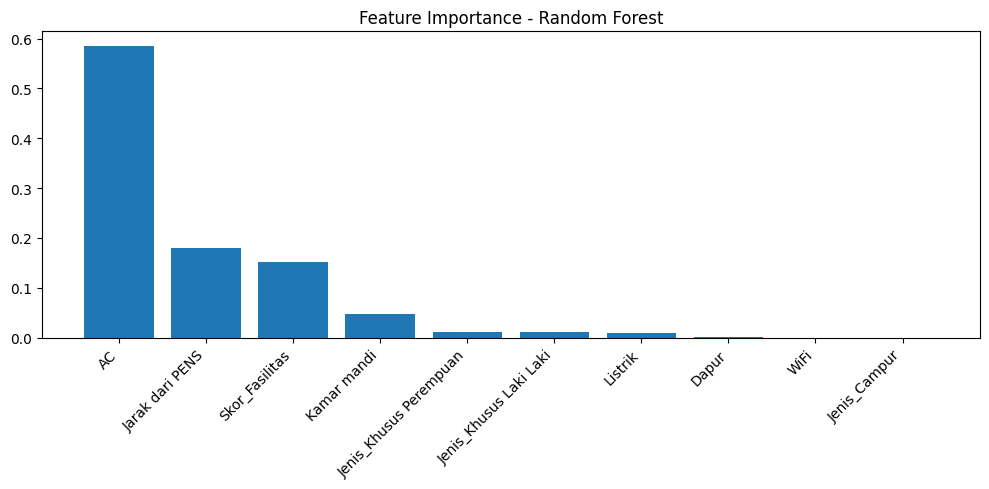

In [21]:
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]
fitur_names = [fitur_regresi[i] for i in indices]

plt.figure(figsize=(10, 5))
plt.bar(fitur_names, importances[indices])
plt.title("Feature Importance - Random Forest")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

### 6.2 Actual vs Predicted

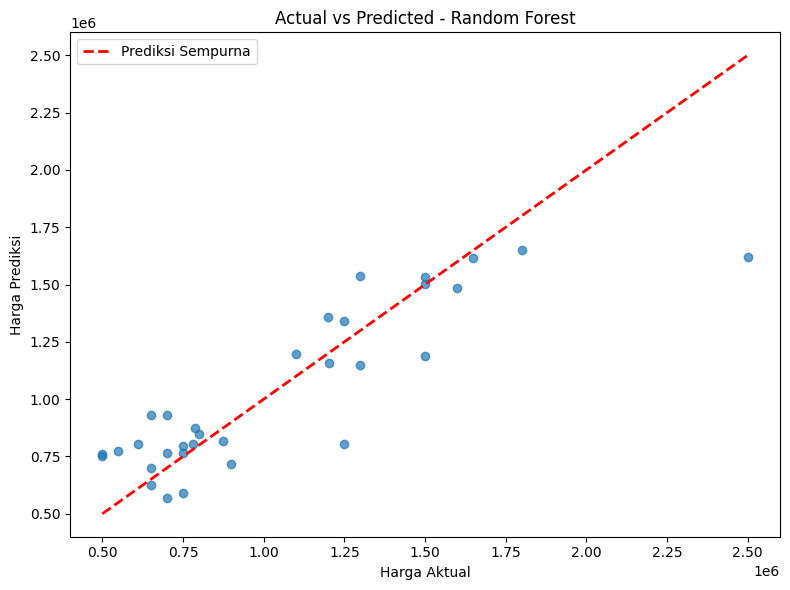

In [22]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred, alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--", linewidth=2, label="Prediksi Sempurna"
)
plt.xlabel("Harga Aktual")
plt.ylabel("Harga Prediksi")
plt.title("Actual vs Predicted - Random Forest")
plt.legend()
plt.tight_layout()
plt.savefig("actual_vs_predicted.png")
plt.show()

### 6.3 Silhouette Plot

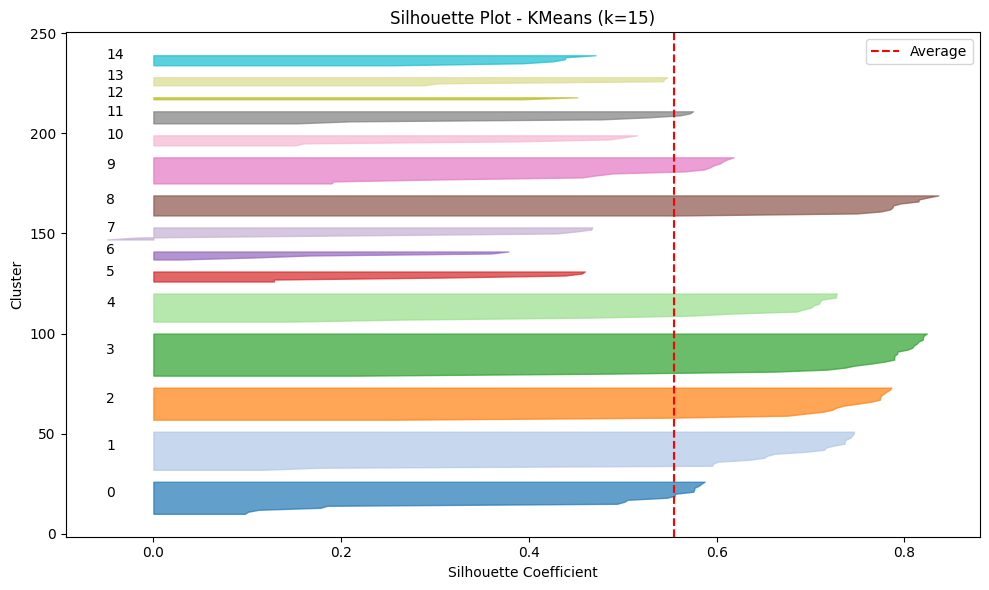

In [23]:
X_sil = X_cluster
kmeans_sil = KMeans(n_clusters=15, random_state=42, n_init=10)
labels_sil = kmeans_sil.fit_predict(X_sil)
silhouette_vals = silhouette_samples(X_sil, labels_sil)

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10

for i in range(15):
    cluster_vals = sorted(silhouette_vals[labels_sil == i])
    size = len(cluster_vals)
    y_upper = y_lower + size
    color = cm.tab20(i / 15)
    ax.fill_betweenx(range(y_lower, y_upper), 0, cluster_vals, color=color, alpha=0.7)
    ax.text(-0.05, y_lower + size / 2, str(i))
    y_lower = y_upper + 5

ax.axvline(x=silhouette_vals.mean(), color="red", linestyle="--", label="Average")
ax.set_title("Silhouette Plot - KMeans (k=15)")
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Cluster")
ax.legend()
plt.tight_layout()
plt.savefig("silhouette_plot.png")
plt.show()

### 6.4 Learning Curve

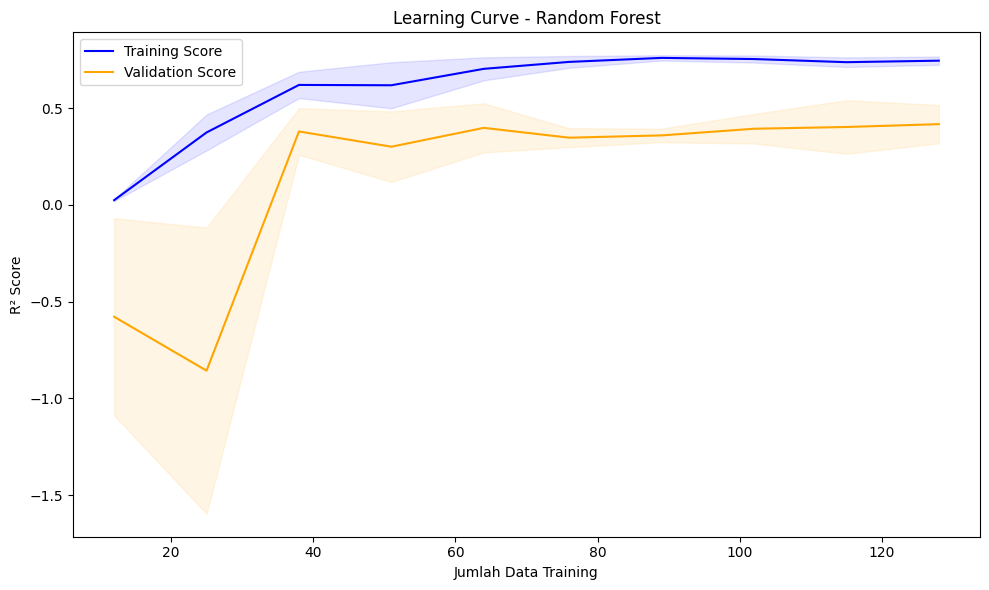

In [24]:
train_sizes, train_scores, test_scores = learning_curve(
    best_rf, X, y,
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean  = test_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
test_std   = test_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label="Training Score", color="blue")
plt.plot(train_sizes, test_mean, label="Validation Score", color="orange")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="orange")
plt.xlabel("Jumlah Data Training")
plt.ylabel("R² Score")
plt.title("Learning Curve - Random Forest")
plt.legend()
plt.tight_layout()
plt.savefig("learning_curve.png")
plt.show()

## 7. MLflow Logging

In [25]:
mlflow.set_experiment("KosMate")

with mlflow.start_run():

    mlflow.log_params(grid.best_params_)

    mlflow.log_metric("r2", r2)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("mape", mape)
    mlflow.log_metric("silhouette_score", silhouette_score(X_cluster, cluster))

    mlflow.sklearn.log_model(best_rf, "model_rf")
    mlflow.sklearn.log_model(kmeans, "model_kmeans")

    mlflow.log_artifact("feature_importance.png")
    mlflow.log_artifact("actual_vs_predicted.png")
    mlflow.log_artifact("silhouette_plot.png")
    mlflow.log_artifact("learning_curve.png")

    print("MLflow berhasil dicatat!")

2026/05/20 15:48:05 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/20 15:48:05 INFO mlflow.store.db.utils: Updating database tables
2026/05/20 15:48:10 INFO mlflow.tracking.fluent: Experiment with name 'KosMate' does not exist. Creating a new experiment.
2026/05/20 15:48:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/20 15:48:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/20 15:48:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/20 15:48:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickl

MLflow berhasil dicatat!


## 8. Input User & Rekomendasi Kos

In [ ]:
jarak       = float(input("Jarak dari PENS : "))
jenis       = input("Jenis Kos : ")
wifi        = input("WiFi (Ada/Tidak) : ")
ac          = input("AC (Ada/Tidak) : ")
dapur       = input("Dapur (Ada/Tidak) : ")
listrik     = input("Listrik (Include/Exclude) : ")
kamar_mandi = input("Kamar mandi (Dalam/Luar) : ")

input_user = pd.DataFrame({
    "Jarak dari PENS": [jarak],
    "Jenis": [jenis],
    "WiFi": [wifi],
    "AC": [ac],
    "Dapur": [dapur],
    "Listrik": [listrik],
    "Kamar mandi": [kamar_mandi]
})

input_user["WiFi"]        = input_user["WiFi"].map(mapping_ada)
input_user["AC"]          = input_user["AC"].map(mapping_ada)
input_user["Dapur"]       = input_user["Dapur"].map(mapping_ada)
input_user["Listrik"]     = input_user["Listrik"].map(mapping_listrik)
input_user["Kamar mandi"] = input_user["Kamar mandi"].map(mapping_km)

input_user["Skor_Fasilitas"] = (
    input_user["WiFi"] +
    input_user["AC"] +
    input_user["Dapur"] +
    input_user["Kamar mandi"]
)

input_user = pd.get_dummies(input_user, columns=["Jenis"])

input_user = input_user.reindex(
    columns=fitur_regresi,
    fill_value=0
)

prediksi_harga = best_rf.predict(input_user)[0]

print("\n" + "=" * 50)
print("PREDIKSI HARGA")
print("=" * 50)
print(f"Estimasi Harga : Rp {prediksi_harga:,.0f}")

input_cluster = input_user.copy()
input_cluster["Harga"] = prediksi_harga
input_cluster = input_cluster.reindex(
    columns=fitur_cluster,
    fill_value=0
)

input_scaled = scaler.transform(input_cluster)
cluster_pred = kmeans.predict(input_scaled)[0]

print("\n" + "=" * 50)
print("HASIL CLUSTER")
print("=" * 50)
print(f"Masuk Cluster : {cluster_pred}")

hasil_rekomendasi = df[
    df["Cluster_KMeans"] == cluster_pred
][[
    "Nama Kos",
    "Jenis",
    "Harga",
    "Jarak dari PENS",
    "WiFi",
    "AC",
    "Dapur",
    "Listrik",
    "Kamar mandi"
]]

print("\n" + "=" * 50)
print("REKOMENDASI KOS")
print("=" * 50)
display(
    hasil_rekomendasi
    .sort_values(by="Harga")
)


PREDIKSI HARGA
Estimasi Harga : Rp 1,445,098

HASIL CLUSTER
Masuk Cluster : 8

REKOMENDASI KOS


,Nama Kos,Jenis,Harga,Jarak dari PENS,WiFi,AC,Dapur,Listrik,Kamar mandi
139,Kost Ratna Cempaka,Khusus Perempuan,1075000,1.1,Ada,Ada,Ada,Exclude,Luar
48,Kos Muslimah,Khusus Perempuan,1100000,2.5,Ada,Ada,Ada,Exclude,Luar
91,Kost Mulyosari Mas Mulyorejo,Khusus Perempuan,1200000,1.5,Ada,Ada,Ada,Exclude,Luar
105,Kost Tannara I Tipe D,Khusus Perempuan,1250000,2.0,Ada,Ada,Ada,Exclude,Luar
117,Kost Klaris Tipe C,Khusus Perempuan,1300000,1.6,Ada,Ada,Ada,Exclude,Luar
83,Kost Mykost Wisma Permai Tipe D,Khusus Perempuan,1400000,0.6,Ada,Ada,Ada,Exclude,Luar
1,Kos The Gayam,Khusus Perempuan,1600000,2.4,Ada,Ada,Ada,Exclude,Luar
84,Kost Rainbow,Khusus Perempuan,1600000,0.7,Ada,Ada,Ada,Exclude,Luar
113,Kost Puspita Tipe B,Khusus Perempuan,1600000,1.9,Ada,Ada,Ada,Exclude,Luar
74,Kost Eksklusif Dharmahusada,Khusus Perempuan,1750000,1.2,Ada,Ada,Ada,Exclude,Luar
